***Student Mental Health***

This dataset collects university students’ responses about:

* Gender

* Age

* CGPA / academic performance

* Marital status

* Mental health indicators (Depression, Anxiety, Panic attacks)

* Treatment-seeking behavior

It is a relatively small sample ( n ~ 101), but let's search for insights into students’ mental health in connection with academic performance.


In [61]:
# Import necessary libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import seaborn as sns

print('Libraries imported')

Libraries imported


In [62]:
df = pd.read_csv('Student Mental health.csv')

# Check the first few rows
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


#Dataset Overview

In [63]:
# shape - how big is the dataframe?
print(f'Size: {df.shape[0]} rows x  {df.shape[1]} columns')

Size: 101 rows x  11 columns


In [64]:
print("\nSummary on columns names, nulls and data types\n")
print(df.info())


Summary on columns names, nulls and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Pani

In [65]:
print("\nDataset columns:")
print(df.columns)


Dataset columns:
Index(['Timestamp', 'Choose your gender', 'Age', 'What is your course?',
       'Your current year of Study', 'What is your CGPA?', 'Marital status',
       'Do you have Depression?', 'Do you have Anxiety?',
       'Do you have Panic attack?',
       'Did you seek any specialist for a treatment?'],
      dtype='object')


#Data Cleaning + Feature Engineering

In [66]:
# Renaming  to more appropriate column names

df.rename(columns={
    'Timestamp': 'timestamp',
    'Choose your gender': 'gender',
    'Age': 'age',
    'What is your course?': 'course',
    'Your current year of Study': 'year_of_study',
    'What is your CGPA?': 'cgpa',
    'Marital status': 'marital_status',
    'Do you have Depression?': 'depression',
    'Do you have Anxiety?': 'anxiety',
    'Do you have Panic attack?': 'panic_attack',
    'Did you seek any specialist for a treatment?': 'treatment_sought'
}, inplace=True)

In [67]:
print(df.columns)  #names ok

Index(['timestamp', 'gender', 'age', 'course', 'year_of_study', 'cgpa',
       'marital_status', 'depression', 'anxiety', 'panic_attack',
       'treatment_sought'],
      dtype='object')


In [68]:
# == Handling missing values and removing duplicates if needed. ==

# == Count duplicates==
print(f'\nDuplicate rows: {df.duplicated().sum()}')

print(f'\nThere are no duplicate records in the dataframe')


Duplicate rows: 0

There are no duplicate records in the dataframe


In [69]:
#== Handle missing values ==
print(df.isnull().sum())

#One  missing value in age

timestamp           0
gender              0
age                 1
course              0
year_of_study       0
cgpa                0
marital_status      0
depression          0
anxiety             0
panic_attack        0
treatment_sought    0
dtype: int64


In [70]:
# Missing treatment in Age

# Calculate the median of age, ignoring NA
median_age = df['age'].median()
print(f"Age's median: {median_age}")

# Replace NA with the median
df['age'] = df['age'].fillna(median_age)

# Check
print(f'Missing in age after imputation: {df['age'].isna().sum()}') # 0


Age's median: 19.0
Missing in age after imputation: 0


In [71]:
# Cleaning => year_of_study

# Extract only numbers from the 'year_of_study' column
df['year_of_study_num'] = df['year_of_study'].str.extract(r'(\d+)').astype(int)  #now data type int


In [72]:
# checking

print(df[['year_of_study', 'year_of_study_num']].head(10))

missing = df['year_of_study_num'].isna().sum()
print(f"\nValues ​​without extracted number:: {missing}")

# View the extracted unique values
print("\nExtracted unique values:")
print(df['year_of_study_num'].unique())

  year_of_study  year_of_study_num
0        year 1                  1
1        year 2                  2
2        Year 1                  1
3        year 3                  3
4        year 4                  4
5        Year 2                  2
6        year 2                  2
7        year 1                  1
8        Year 2                  2
9        year 1                  1

Values ​​without extracted number:: 0

Extracted unique values:
[1 2 3 4]


In [73]:
df['cgpa'].unique()

# array(['3.00 - 3.49', '3.50 - 4.00', '3.50 - 4.00 ', '2.50 - 2.99', 2.00 - 2.49', '0 - 1.99'], dtype=object)

array(['3.00 - 3.49', '3.50 - 4.00', '3.50 - 4.00 ', '2.50 - 2.99',
       '2.00 - 2.49', '0 - 1.99'], dtype=object)

In [74]:
# Cleaning => cgpa

# Clean up spaces and merge duplicates
df['cgpa'] = df['cgpa'].str.strip()  # Remove leading and trailing spaces

# Get unique values ​​sorted from smallest to largest according to the first number in the range
unique_ranges = df['cgpa'].unique()
sorted_ranges = sorted(unique_ranges, key=lambda x: float(x.split('-')[0].strip()))

# Convert to sorted category
df['cgpa'] = pd.Categorical(df['cgpa'], categories=sorted_ranges, ordered=True)


In [75]:
# checking

print("Unique values ​​sorted and clean:")
print(df['cgpa'].cat.categories)

print("\nCGPA range count:")
print(df['cgpa'].value_counts().sort_index())


Unique values ​​sorted and clean:
Index(['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99', '3.00 - 3.49', '3.50 - 4.00'], dtype='object')

CGPA range count:
cgpa
0 - 1.99        4
2.00 - 2.49     2
2.50 - 2.99     4
3.00 - 3.49    43
3.50 - 4.00    48
Name: count, dtype: int64


In [76]:
# Conversion to datetime format (23 values ​​are lost during the process).

df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, errors='coerce')

# Check
print(f"Null values ​​after conversion: {df['timestamp'].isna().sum()}")


Null values ​​after conversion: 23


In [77]:
# Transformation to more appropriate data types

df['gender'] = df['gender'].astype('category')

df['age'] = df['age'].astype('Int64')

df['course'] = df['course'].astype('string')

df['year_of_study'] = df['year_of_study_num'].astype('category')

df['marital_status'] = df['marital_status'].astype('category')

df['depression'] = df['depression'].astype('category')

df['anxiety'] = df['anxiety'].astype('category')

df['panic_attack'] = df['panic_attack'].astype('category')

df['treatment_sought'] = df['treatment_sought'].astype('category')

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          78 non-null     datetime64[ns]
 1   gender             101 non-null    category      
 2   age                101 non-null    Int64         
 3   course             101 non-null    string        
 4   year_of_study      101 non-null    category      
 5   cgpa               101 non-null    category      
 6   marital_status     101 non-null    category      
 7   depression         101 non-null    category      
 8   anxiety            101 non-null    category      
 9   panic_attack       101 non-null    category      
 10  treatment_sought   101 non-null    category      
 11  year_of_study_num  101 non-null    int64         
dtypes: Int64(1), category(8), datetime64[ns](1), int64(1), string(1)
memory usage: 5.3 KB


In [79]:
# == quantitative vs qualitative data within the dataset.==

quantitative = df.select_dtypes(include='number').columns
qualitative = df.select_dtypes(exclude='number').columns

print("Quantitative columns:", quantitative)
print("Qualitative columns:", qualitative)

Quantitative columns: Index(['age', 'year_of_study_num'], dtype='object')
Qualitative columns: Index(['timestamp', 'gender', 'course', 'year_of_study', 'cgpa',
       'marital_status', 'depression', 'anxiety', 'panic_attack',
       'treatment_sought'],
      dtype='object')


# Exploratory Analysis

In [80]:
# -----------------------------
#  Global context and style
# -----------------------------

#  Matplotlib/Seaborn plots appear inside the notebook, right below the cell where you generate them.
%matplotlib inline

sns.set_context("paper", font_scale=0.8)

sns.set_style("whitegrid")

sns.set_palette("Set2")
    # Set1, Set2, Set3 → bold and distinct colors
    # Pastel1, Pastel2 → softer tones
    # Dark2, Accent → corporate, understated tones

    # Paletas secuenciales (para gradientes, para variables con orden (ejemplo: ingresos) )
    # sns.set_palette("Blues")      # light blue → dark blue
    # sns.set_palette("Greens")
    # sns.set_palette("Reds")
    # sns.set_palette("Purples")
    # sns.set_palette("Oranges")

# Default size of all figures
plt.rcParams["figure.figsize"] = (6,4)  # 6 inches wide, 4 inches high
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 9
plt.rcParams["lines.linewidth"] = 2
plt.rcParams["lines.markersize"] = 4
plt.rcParams["figure.dpi"] = 100   # resolution

sns.despine()  # Remove borders

plt.tight_layout()


<Figure size 600x400 with 0 Axes>

🌟 Exercise 1 : Visualizing the Distribution of CGPA

- Create a histogram to visualize the distribution of students’ CGPA.

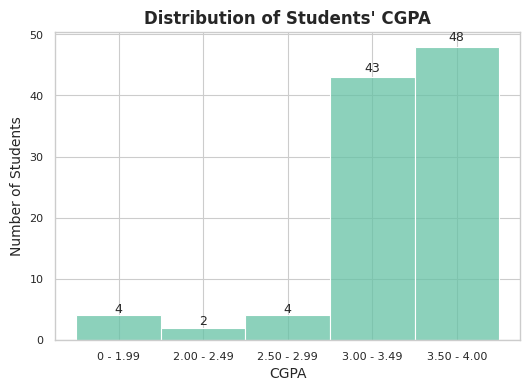

In [81]:
ax = sns.histplot(df['cgpa'], bins=5, kde=False)

# Place numbers above each bar, centered, with a thousands separator and NO decimal places
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width()/2,
        y=height + 0.01*height,
        s=f"{height:,.0f}".replace(",", "X").replace(".", ",").replace("X", "."),
        ha='center',
        va='bottom',
        fontsize=9

    )

plt.title("Distribution of Students' CGPA")
plt.xlabel("CGPA")
plt.ylabel("Number of Students")

plt.show()

🌟 Exercise 2: Comparing Anxiety Levels Across Different Genders
* Use a bar plot to compare the proportion of students experiencing anxiety across different genders.

Anxiety according Gender
   gender anxiety  Proportion
0  Female      No       0.680
1  Female     Yes       0.320
2    Male      No       0.615
3    Male     Yes       0.385


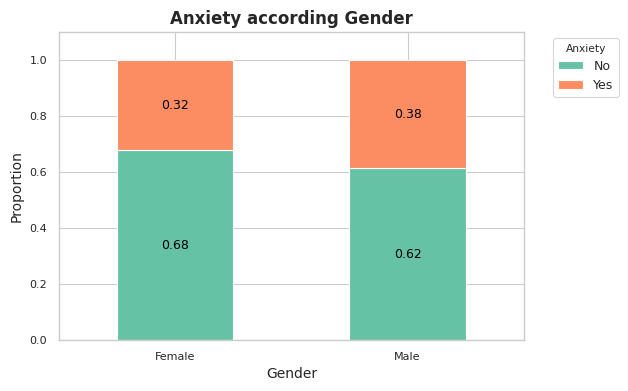

In [82]:
#proportion table
anxiety_by_gender  = (
    df.groupby('gender', observed=True)['anxiety']
    .value_counts(normalize=True)
    .rename("Proportion")
    .reset_index()
)

print('Anxiety according Gender')
print(anxiety_by_gender.round(3))

# Pivot the table
anxiety_pivot = anxiety_by_gender.pivot(index='gender', columns='anxiety', values='Proportion')

# Graph
ax = anxiety_pivot.plot(
    kind='bar',
    stacked=True
)

# proportion inside bars
for p in ax.patches:
    height = p.get_height()
    y_pos = p.get_y() + height / 2  #centered v
    ax.text(
        x=p.get_x() + p.get_width()/2,  #centered h
        y=y_pos,
        s=f"{height:.2f}",
        ha='center',
        va='center',
        fontsize=9,
        color='black'
    )

plt.title('Anxiety according Gender')
plt.ylabel("Proportion")
plt.xlabel("Gender")
plt.ylim(0, 1.1)

plt.xticks(rotation=0)  # Horizontal X-axis (no rotation)

plt.legend(title='Anxiety', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


🌟 Exercise 3: Exploring the Relationship Between Age and Panic Attacks
* Create a scatter plot to explore if there’s any visible relationship between students’ age and the occurrence of panic attacks.

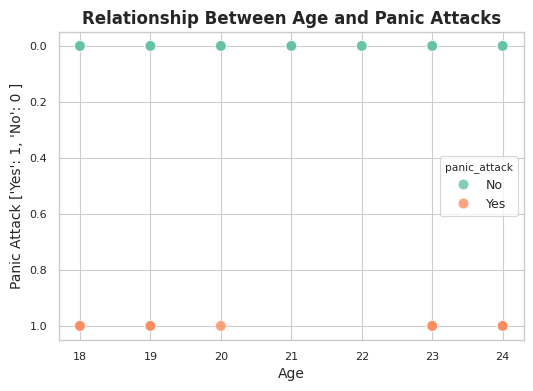


A scatter plot is not the best graph option for binary variables in y; a boxplot should be used instead.



In [83]:
# Convert Yes/No to numeric 1/0
df['panic_attack_num'] = df['panic_attack'].map({'Yes': 1, 'No': 0})

ax = sns.scatterplot(
    data=df,
    x='age',
    y='panic_attack_num',
    hue='panic_attack',
    s=60,        # dot size
    alpha=0.8    # transparency to see overlaps
)

plt.title("Relationship Between Age and Panic Attacks")
plt.xlabel("Age")
plt.ylabel("Panic Attack ['Yes': 1, 'No': 0 ]")

plt.show()

print('\nA scatter plot is not the best graph option for binary variables in y; a boxplot should be used instead.\n')


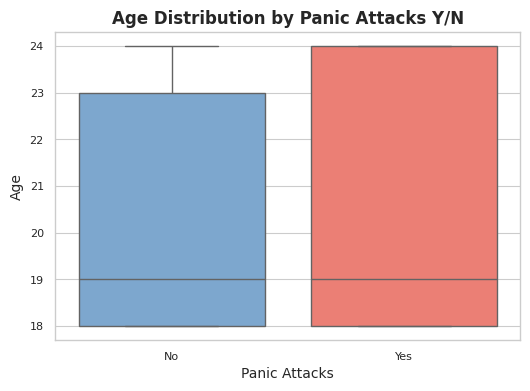

In [84]:
sns.boxplot(
    data=df,
    x='panic_attack',
    y='age',
    hue='panic_attack',
    palette={'Yes':'#FF6F61', 'No':'#6FA8DC'},
    dodge=False    # does not separate boxes, each category remains on its axis
)

plt.title("Age Distribution by Panic Attacks Y/N")
plt.xlabel("Panic Attacks")
plt.ylabel("Age")

plt.show()


🌟 Exercise 4: Visualizing Pairwise Relationships with Pair Plot
* Try to understand the relationships between students’ ages, CGPAs, and their mental health status regarding depression, anxiety, and panic attacks.

In [85]:
df.columns

Index(['timestamp', 'gender', 'age', 'course', 'year_of_study', 'cgpa',
       'marital_status', 'depression', 'anxiety', 'panic_attack',
       'treatment_sought', 'year_of_study_num', 'panic_attack_num'],
      dtype='object')

age                   Int64
cgpa_num            float64
depression_num        int64
anxiety_num           int64
panic_attack_num      int64
dtype: object


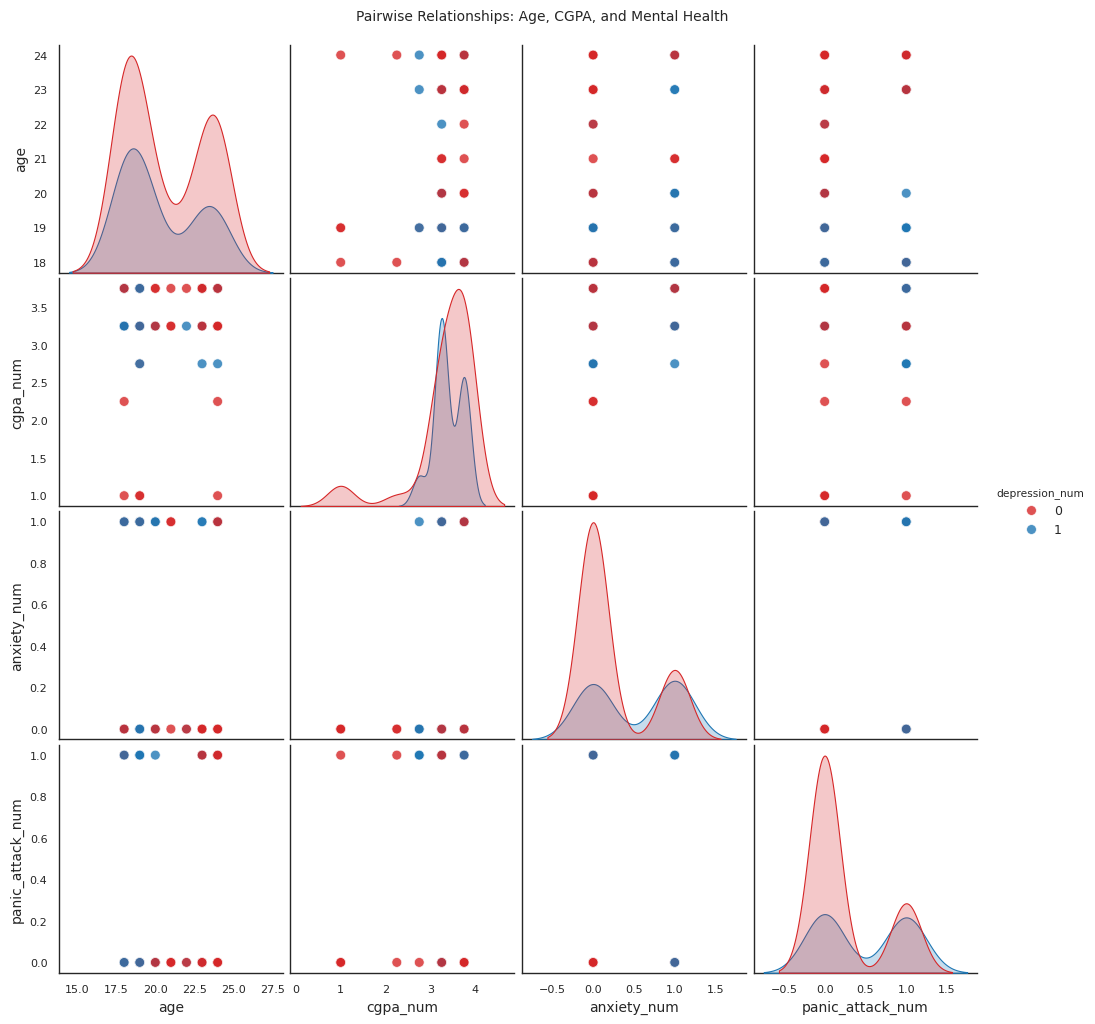

In [86]:
# Convert categorial mental health columns to numeric
df['depression_num'] = df['depression'].map({"Yes": 1, "No": 0})
df['anxiety_num'] = df['anxiety'].map({"Yes": 1, "No": 0})
#panic_attack_num = from previus excercise

# Convert CGPA ranges to numeric midpoint values
cgpa_map = {
       '0 - 1.99': 1.0,
    '2.00 - 2.49': 2.25,
    '2.50 - 2.99': 2.75,
    '3.00 - 3.49': 3.25,
    '3.50 - 4.00': 3.75
}

df["cgpa_num"] = df['cgpa'].map(cgpa_map)


# Create a subset and force all columns to numeric
subset = df[["age", "cgpa_num", "depression_num", "anxiety_num", "panic_attack_num"]].copy()
subset = subset.apply(pd.to_numeric, errors='coerce') # converts to int/float, NaN if it cannot

# Check types
print(subset.dtypes)

## == Graph ==
sns.set_style("white")  # Clean background without grid lines

sns.pairplot(
    subset,
    hue='depression_num',
    diag_kind='kde',
    palette=["#D62728", "#1F77B4"],  # intense red and blue
    plot_kws={'alpha':0.8, 's':50}
)

plt.suptitle("Pairwise Relationships: Age, CGPA, and Mental Health", y=1.02, fontsize=10)
plt.show()


🌟 Exercise 5: Heatmap to Visualize Correlations
* Create a heatmap that visualizes the correlation matrix of students’ age, CGPA, and mental health status indicators.

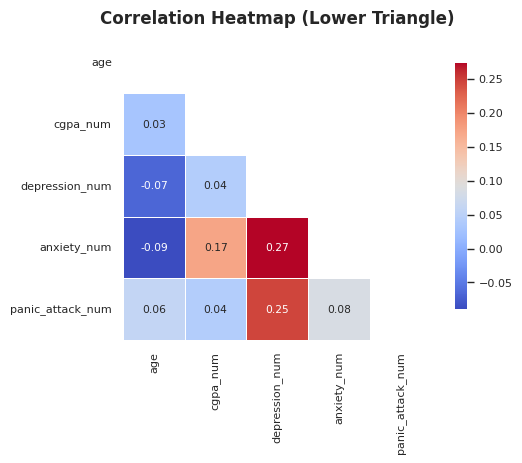

In [87]:
# Correlation matrix
corr_matrix = subset.corr()

sns.heatmap(
    corr_matrix,
    mask= np.triu(np.ones_like(corr_matrix, dtype=bool)) , # Keep only the bottom triangle, for better readability
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Heatmap (Lower Triangle)")
plt.show()


🌟 Exercise 6: Analyzing Distributions and Relationships Using FacetGrid
* Explore the distribution of CGPA across different levels of depression status using Seaborn’s FacetGrid.

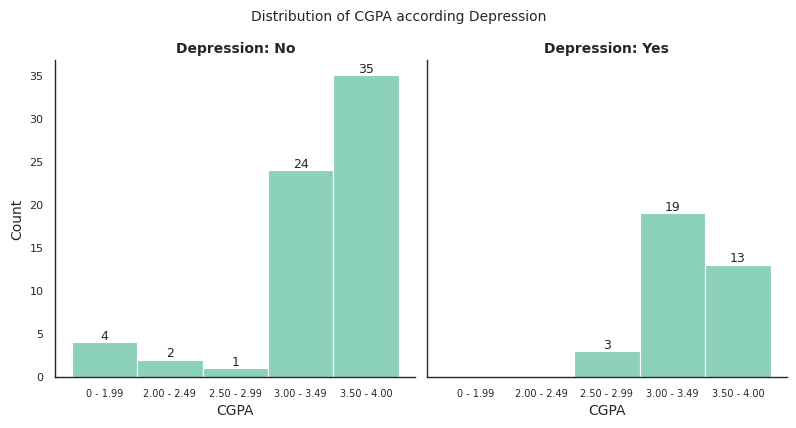

In [88]:
g = sns.FacetGrid(df, col="depression", height=4, aspect=1)
g.map_dataframe(
    sns.histplot,
    x="cgpa",
    bins=5
    )

# Ajustes estéticos y etiquetas
for ax in g.axes.flat:

    ax.tick_params(axis='x', labelsize=7)

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2,
                height,
                int(height),
                ha='center',
                va='bottom',
                fontsize=9
            )

g.set_axis_labels("CGPA", "Count")
g.set_titles(col_template="Depression: {col_name}")
g.fig.suptitle("Distribution of CGPA according Depression", y=1.05, fontsize=10)

plt.show()



In [89]:

print(f"Mean:\n{subset.groupby('depression_num')['cgpa_num'].mean()}")
print(f'Median:\n{subset.groupby('depression_num')['cgpa_num'].median()}')
print(f'n size:\n {subset['depression_num'].value_counts()}')

Mean:
depression_num
0    3.340909
1    3.392857
Name: cgpa_num, dtype: float64
Median:
depression_num
0    3.75
1    3.25
Name: cgpa_num, dtype: float64
n size:
 depression_num
0    66
1    35
Name: count, dtype: int64


- - -

#Limitations

* Small sample size (~101).

* Self-reported mental health measures.

* Limited age variability.

* CGPA reported in ranges rather than exact values.

- - -

#Key Insights

* The sample is highly concentrated in upper CGPA ranges (≈90% above 3.00), limiting performance variability.

* Around one third of students report anxiety. Gender differences are modest and may not be statistically meaningful.

* Age does not appear to differ meaningfully between students with and without panic attacks.

* Correlations between age, CGPA, and mental health indicators are weak. However,  Depression ↔ Anxiety and Depression ↔ Panic attacks show moderate positive associations, suggesting symptom co-occurrence.

* No consistent evidence supports a meaningful CGPA difference between students with and without depression; mean values ​​are nearly identical, and distribution shape likely explains median differences.

- - -

#Closing Summary

Mental health indicators tend to co-occur, but their direct relationship with academic performance is weak in this sample. Larger and more diverse datasets would be needed to identify stronger or more generalizable patterns.